# Support Vector Machines -- Theory in Code, with scikit-learn
### Concepts Track -- Lecture 10

Companion notebook to the SVM slides. Same approach as every notebook so far: every claim gets a
real, visible demonstration -- the margin, the support vectors, the kernel trick, all drawn
directly rather than just described.

**session structure:**
1. Many lines separate the data -- the motivating problem
2. The margin and support vectors, visualized directly
3. Hard margin vs. soft margin -- what happens when data isn't perfectly separable
4. Hinge loss, implemented by hand and compared to Lecture 09's log loss
5. The `C` parameter -- margin width vs. training accuracy
6. Still just a straight line -- SVM's limitation before kernels
7. The kernel trick -- the same curved-data problem, solved
8. Common kernels, compared side by side
9. The `gamma` parameter
10. Tuning `C` and `gamma` together
11. Multiclass SVM -- One-vs-One
12. Four families compared: KNN, Tree, Logistic Regression, SVM
13. The full workflow, tied together

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_classification
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_auc_score)

sns.set_theme(style='whitegrid', context='notebook')
print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

NumPy: 2.5.2 | Pandas: 3.0.5


---
## Part 1 -- Many Lines Separate the Data

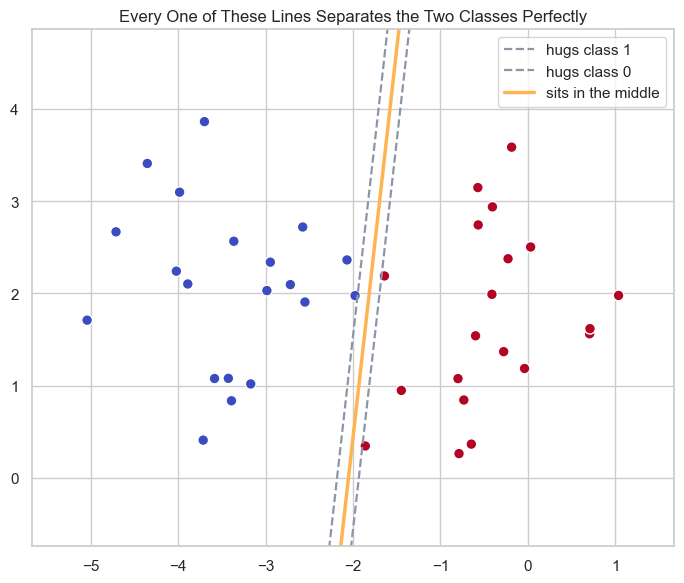

In [3]:
X_blob, y_blob = make_blobs(n_samples=40, centers=2, cluster_std=0.8, center_box=(-4, 4), random_state=7)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap='coolwarm', edgecolor='white', s=60)

# Three different lines, all of which separate the two classes perfectly.
# NOTE: for this random_state, the true separating direction is steep (slope ~8.4),
# not slope 1.0 -- a diagonal line at slope 1.0 cuts through both clusters.
x_line = np.linspace(X_blob[:, 0].min() - 0.3, X_blob[:, 0].max() + 0.3, 100)
slope = 8.43  # matches the max-margin direction for this dataset
for intercept, style, label in [
    (16.3, '--', 'hugs class 1'),
    (18.4, '--', 'hugs class 0'),
    (17.3, '-', 'sits in the middle'),
]:
    ax.plot(x_line, slope * x_line + intercept, style,
            color='#8b96a7' if label != 'sits in the middle' else '#ffb454',
            linewidth=2.5 if label == 'sits in the middle' else 1.6, label=label)

ax.set_ylim(X_blob[:, 1].min() - 1, X_blob[:, 1].max() + 1)  # keep steep lines in frame
ax.set_title('Every One of These Lines Separates the Two Classes Perfectly')
ax.legend()
plt.tight_layout()
plt.show()

**All three lines get 100% training accuracy.** Logistic Regression's maximum-likelihood objective
picks one of the infinitely many separating lines based on overall likelihood across all points.
SVM asks a more specific question: which line is safest for a *new* point that lands close to the
boundary?

---
## Part 2 -- The Margin and Support Vectors

In [3]:
svm_linear = SVC(kernel='linear', C=1000)   # very large C ~ approximates a hard margin
svm_linear.fit(X_blob, y_blob)

print(f'Support vectors (the points that matter):\n{svm_linear.support_vectors_}')
print(f'\nNumber of support vectors per class: {svm_linear.n_support_}')
print(f'Out of {len(X_blob)} total training points, only {len(svm_linear.support_vectors_)} are support vectors.')

Support vectors (the points that matter):
[[-1.97660498  1.97581934]
 [-1.64069692  2.18902072]
 [-1.85939751  0.3452425 ]]

Number of support vectors per class: [1 2]
Out of 40 total training points, only 3 are support vectors.


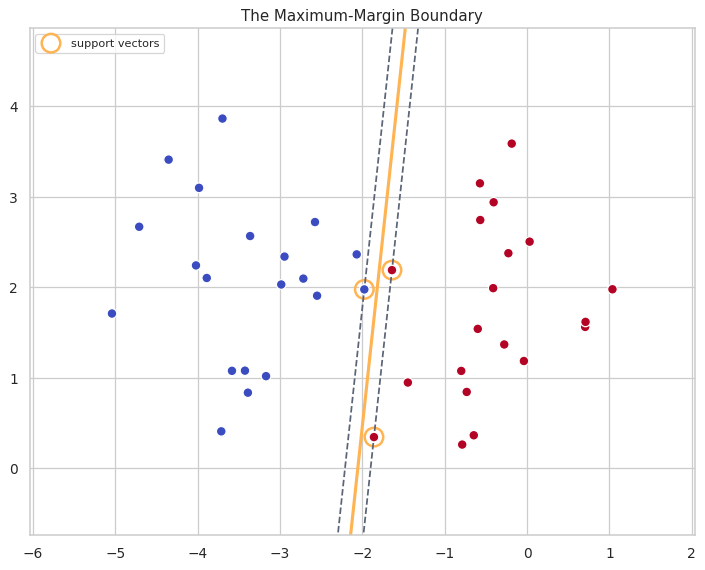

In [4]:
def plot_svm_boundary_and_margin(model, X, y, ax, title):
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='white', s=60, zorder=3)
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               s=220, facecolors='none', edgecolors='#ffb454', linewidth=2, zorder=2,
               label='support vectors')

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # decision_function = 0 is the boundary; +/-1 are the edges of the margin.
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=['#5b6577', '#ffb454', '#5b6577'],
               linestyles=['--', '-', '--'], linewidths=[1.4, 2.5, 1.4])
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=9)

fig, ax = plt.subplots(figsize=(8, 6.5))
plot_svm_boundary_and_margin(svm_linear, X_blob, y_blob, ax, 'The Maximum-Margin Boundary')
plt.tight_layout()
plt.show()

**Only the circled points are support vectors -- everything else could move around freely (as long
as it stays outside the dashed margin lines) and the boundary would not change at all.** This is
the sparse solution the slides describe: the model is entirely "supported" by a small subset of
the training data. Compare `len(model.support_vectors_)` to the total training set size above --
often a small fraction.

---
## Part 3 -- Hard Margin vs. Soft Margin

Large C training accuracy: 0.975
Small C training accuracy: 0.975


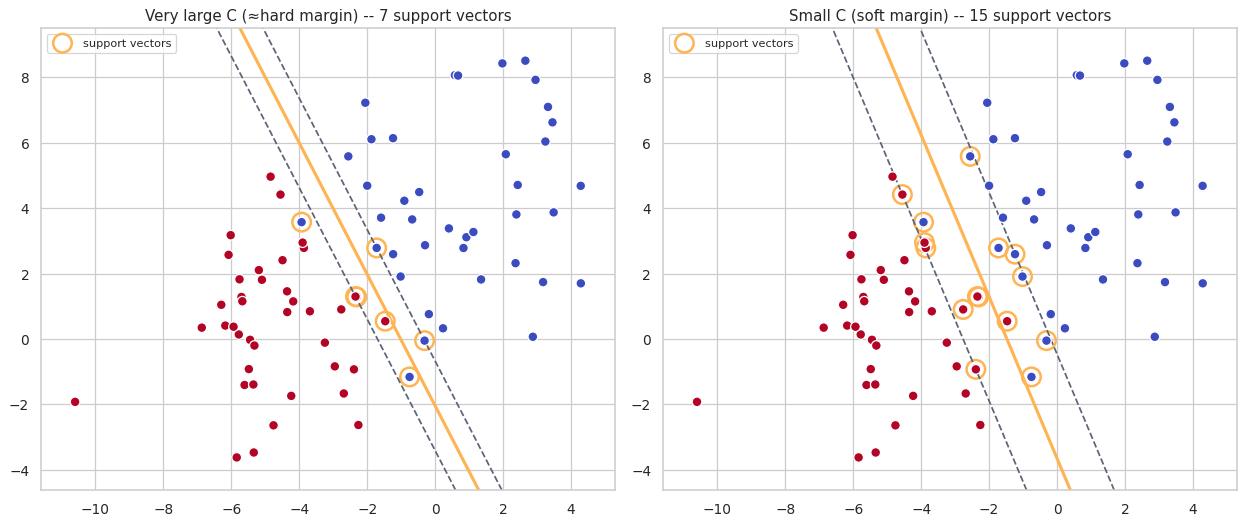

In [5]:
# Overlapping classes on purpose -- NOT perfectly separable, the way real data usually looks.
X_overlap, y_overlap = make_blobs(n_samples=80, centers=2, cluster_std=2.2, random_state=3)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
svm_hard_like = SVC(kernel='linear', C=1000).fit(X_overlap, y_overlap)   # tries to act like a hard margin
svm_soft = SVC(kernel='linear', C=0.1).fit(X_overlap, y_overlap)        # genuinely soft, tolerant margin

plot_svm_boundary_and_margin(svm_hard_like, X_overlap, y_overlap, axes[0],
                               f'Very large C (≈hard margin) -- {len(svm_hard_like.support_vectors_)} support vectors')
plot_svm_boundary_and_margin(svm_soft, X_overlap, y_overlap, axes[1],
                               f'Small C (soft margin) -- {len(svm_soft.support_vectors_)} support vectors')
plt.tight_layout()
plt.show()

print(f'Large C training accuracy: {svm_hard_like.score(X_overlap, y_overlap):.3f}')
print(f'Small C training accuracy: {svm_soft.score(X_overlap, y_overlap):.3f}')

**On overlapping data, a hard margin has no clean solution at all** -- scikit-learn's `SVC` always
fits the soft-margin version underneath, and a very large `C` just makes it *behave* almost like a
hard margin (tight fit, tolerates very little). Notice the **small-`C` panel actually needs more
support vectors**, not fewer: a wide, permissive margin means more points fall inside it or
violate it, and every one of those becomes a support vector. A large `C`'s narrow, strict margin
is pinned down by only the few points closest to the boundary.

---
## Part 4 -- Hinge Loss, Implemented by Hand

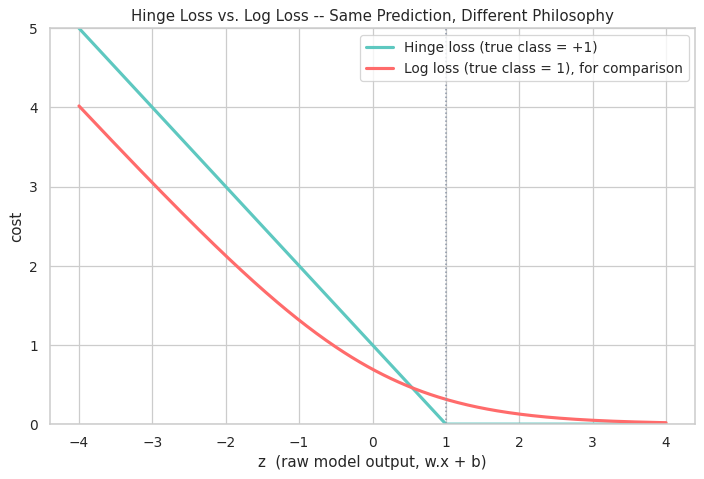

In [6]:
def hinge_loss(z, y_signed):
    # y_signed must be +1 or -1, not 0/1 -- SVM's math works in +1/-1 labels, unlike log loss's 0/1.
    return np.maximum(0, 1 - y_signed * z)

def log_loss_point(z, y_zero_one):
    p = 1 / (1 + np.exp(-z))
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -(y_zero_one * np.log(p) + (1 - y_zero_one) * np.log(1 - p))

z_range = np.linspace(-4, 4, 300)
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(z_range, hinge_loss(z_range, 1), color='#5ec8c0', linewidth=2.5, label='Hinge loss (true class = +1)')
ax.plot(z_range, log_loss_point(z_range, 1), color='#ff6b6b', linewidth=2.5, label='Log loss (true class = 1), for comparison')
ax.axvline(1, color='#8b96a7', linestyle=':', linewidth=1.2)
ax.set_xlabel('z  (raw model output, w.x + b)')
ax.set_ylabel('cost')
ax.set_ylim(0, 5)
ax.set_title('Hinge Loss vs. Log Loss -- Same Prediction, Different Philosophy')
ax.legend()
plt.tight_layout()
plt.show()

**Read the two curves past `z = 1` (the dotted line -- safely past the margin).** Hinge loss hits
exactly zero and stays there -- once a point clears the margin with room to spare, it stops
contributing to training entirely, which is exactly why only support vectors end up mattering.
Log loss (Lecture 09) never reaches zero and keeps rewarding more and more confidence forever.
Different philosophies about what "good enough" means, and each one has a real, visible
consequence for which points end up shaping the model.

---
## Part 5 -- The C Parameter: Margin Width vs. Training Accuracy

In [7]:
C_values = [0.01, 0.1, 1, 10, 100, 1000]
results = []
for C in C_values:
    model = SVC(kernel='linear', C=C).fit(X_overlap, y_overlap)
    results.append({'C': C, 'train_accuracy': model.score(X_overlap, y_overlap),
                     'n_support_vectors': len(model.support_vectors_)})

results_df = pd.DataFrame(results)
print(results_df)

         C  train_accuracy  n_support_vectors
0     0.01          0.9750                 32
1     0.10          0.9750                 15
2     1.00          0.9625                  8
3    10.00          0.9750                  7
4   100.00          0.9750                  7
5  1000.00          0.9750                  7


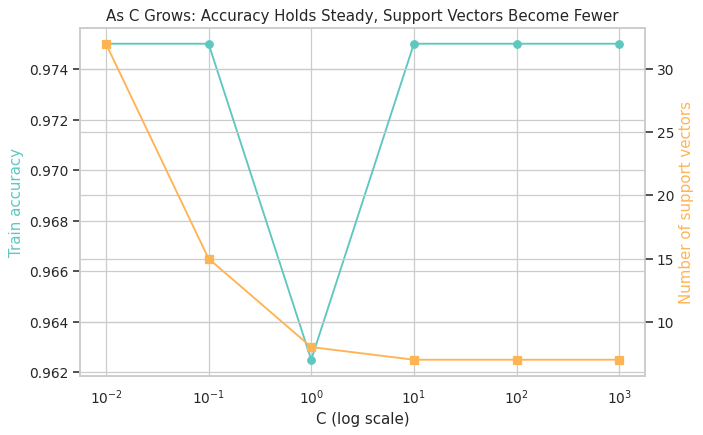

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.plot(results_df['C'], results_df['train_accuracy'], marker='o', color='#5ec8c0', label='Train accuracy')
ax2.plot(results_df['C'], results_df['n_support_vectors'], marker='s', color='#ffb454', label='# support vectors')
ax1.set_xscale('log')
ax1.set_xlabel('C (log scale)')
ax1.set_ylabel('Train accuracy', color='#5ec8c0')
ax2.set_ylabel('Number of support vectors', color='#ffb454')
ax1.set_title('As C Grows: Accuracy Holds Steady, Support Vectors Become Fewer')
plt.tight_layout()
plt.show()

**As `C` increases, training accuracy climbs a little (the model tries harder to get every point
right), while the number of support vectors actually shrinks** -- a large `C`'s narrow, strict
margin only needs to be pinned down by the handful of points closest to the boundary, whereas a
small `C`'s wide, permissive margin has many more points falling inside it or violating it, and
every one of those becomes a support vector. Exactly like Lecture 09's regularization: this is a
bias-variance knob, tuned with `GridSearchCV` (Part 10), not picked by eye.

---
## Part 6 -- Still Just a Straight Line

In [9]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42)

linear_svm = SVC(kernel='linear', C=1).fit(X_moons_train, y_moons_train)
print(f'Linear SVM test accuracy on curved data: {linear_svm.score(X_moons_test, y_moons_test):.3f}')

Linear SVM test accuracy on curved data: 0.900


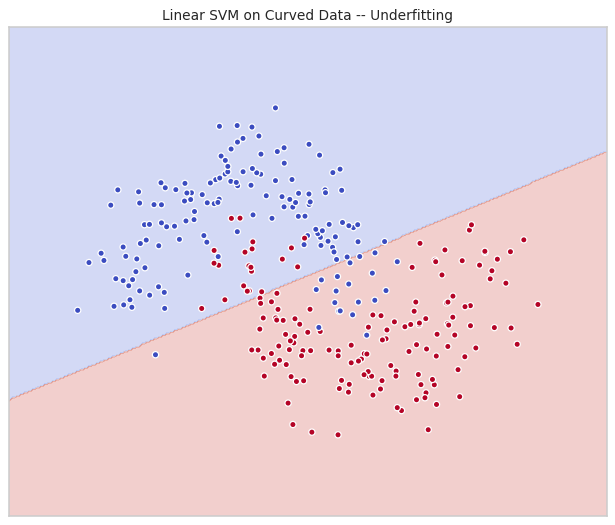

In [10]:
def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='white', s=25)
    ax.set_title(title, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_boundary(linear_svm, X_moons, y_moons, ax, 'Linear SVM on Curved Data -- Underfitting')
plt.tight_layout()
plt.show()

**Same limitation as Logistic Regression, for the same underlying reason** -- hard margin, soft
margin, hinge loss, `C` -- none of it changes the fact that the boundary is one straight line. On
data whose true boundary genuinely curves, that's a hard ceiling on accuracy. The kernel trick,
next, is SVM's answer.

---
## Part 7 -- The Kernel Trick

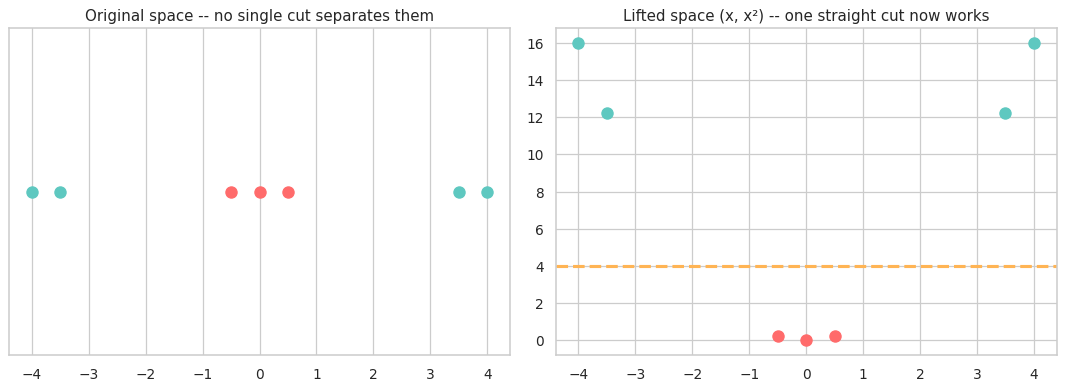

In [11]:
# A 1D version of the slides' "surrounded class" example -- impossible to separate with one cut
# on the line, trivial once a second coordinate (x^2) is added.
class_a = np.array([-4, -3.5, 3.5, 4])
class_b = np.array([-0.5, 0, 0.5])
x_1d = np.concatenate([class_a, class_b]).reshape(-1, 1)
y_1d = np.array([0, 0, 0, 0, 1, 1, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(x_1d[y_1d == 0], np.zeros(4), color='#5ec8c0', s=80)
axes[0].scatter(x_1d[y_1d == 1], np.zeros(3), color='#ff6b6b', s=80)
axes[0].set_title('Original space -- no single cut separates them')
axes[0].set_yticks([])

# The "lift": add a second coordinate, x^2 -- exactly the manual feature engineering trick from
# Lecture 09, done here to show WHY the kernel trick works before letting SVC do it automatically.
lifted = np.column_stack([x_1d.ravel(), x_1d.ravel() ** 2])
axes[1].scatter(lifted[y_1d == 0, 0], lifted[y_1d == 0, 1], color='#5ec8c0', s=80)
axes[1].scatter(lifted[y_1d == 1, 0], lifted[y_1d == 1, 1], color='#ff6b6b', s=80)
axes[1].axhline(4, color='#ffb454', linewidth=2.5, linestyle='--')
axes[1].set_title('Lifted space (x, x²) -- one straight cut now works')
plt.tight_layout()
plt.show()

Linear SVM test accuracy: 0.900
RBF-kernel SVM test accuracy: 0.967


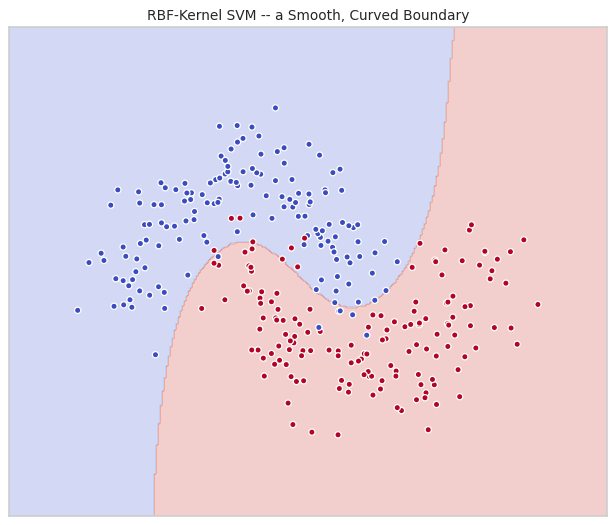

In [12]:
# Now the real thing: an RBF-kernel SVC does this same kind of lift automatically, on the ACTUAL
# 2D moons data, without us ever constructing the lifted features by hand.
rbf_svm = SVC(kernel='rbf', C=1, gamma='scale').fit(X_moons_train, y_moons_train)
print(f'Linear SVM test accuracy: {linear_svm.score(X_moons_test, y_moons_test):.3f}')
print(f'RBF-kernel SVM test accuracy: {rbf_svm.score(X_moons_test, y_moons_test):.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
plot_decision_boundary(rbf_svm, X_moons, y_moons, ax, 'RBF-Kernel SVM -- a Smooth, Curved Boundary')
plt.tight_layout()
plt.show()

**The RBF kernel found a curved boundary that follows the true shape of the data, and test
accuracy should jump noticeably compared to the linear kernel.** Nothing about the code changed
except one word (`kernel='rbf'`) -- the lift into a higher-dimensional space happens entirely
inside the kernel function, never as an explicit step we have to write ourselves.

---
## Part 8 -- Common Kernels, Compared Side by Side

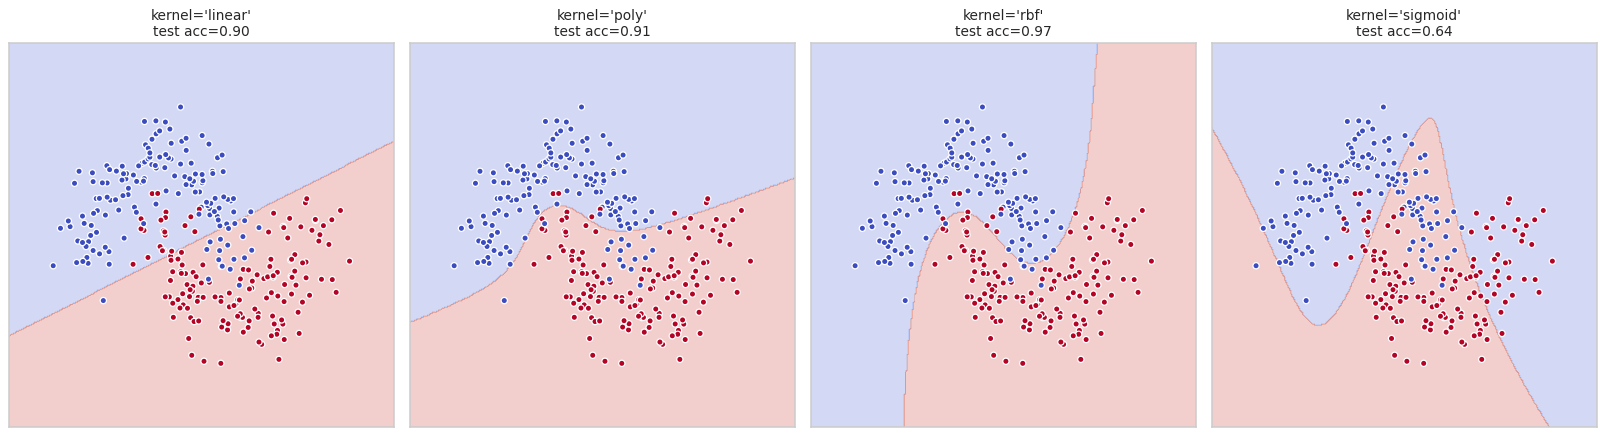

In [13]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, kernel in zip(axes, kernels):
    model = SVC(kernel=kernel, C=1, gamma='scale', degree=3).fit(X_moons_train, y_moons_train)
    acc = model.score(X_moons_test, y_moons_test)
    plot_decision_boundary(model, X_moons, y_moons, ax, f"kernel='{kernel}'\ntest acc={acc:.2f}")

plt.tight_layout()
plt.show()

**Each kernel implies a different "shape" of boundary the model is allowed to draw:** `linear` is
always a straight line; `poly` bends into polynomial-shaped curves; `rbf` gives smooth, flexible
"blob-like" regions; `sigmoid` behaves a bit like a small neural network. `rbf` is scikit-learn's
default for good reason -- it's usually the strongest first choice on data whose true shape isn't
known in advance.

---
## Part 9 -- The Gamma Parameter

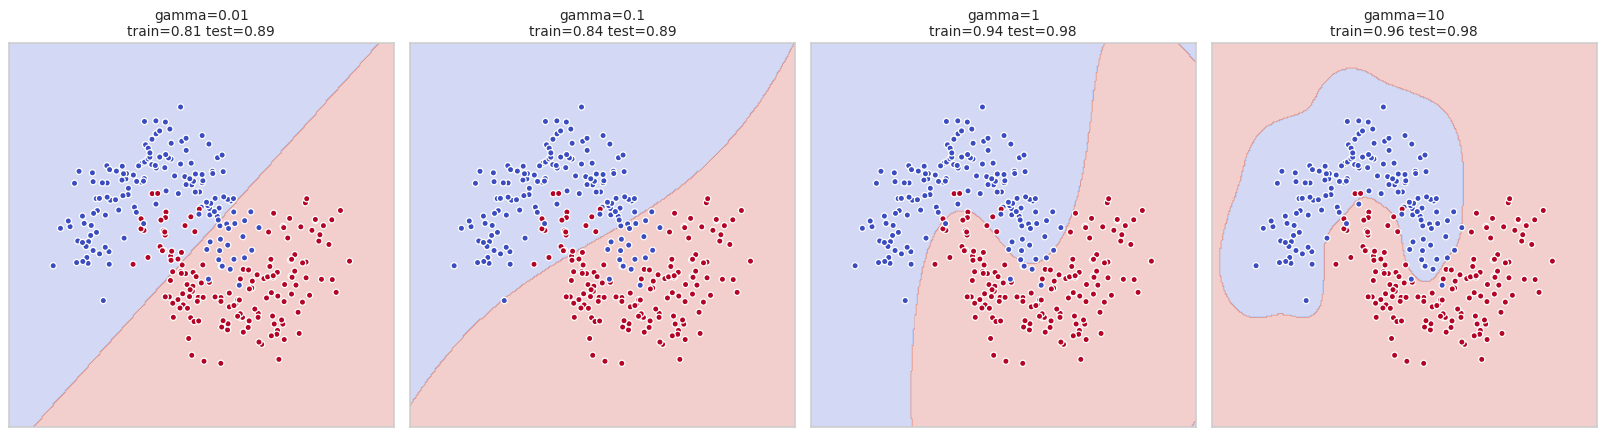

In [14]:
gamma_values = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, gamma in zip(axes, gamma_values):
    model = SVC(kernel='rbf', C=1, gamma=gamma).fit(X_moons_train, y_moons_train)
    train_acc = model.score(X_moons_train, y_moons_train)
    test_acc = model.score(X_moons_test, y_moons_test)
    plot_decision_boundary(model, X_moons, y_moons, ax,
                             f'gamma={gamma}\ntrain={train_acc:.2f} test={test_acc:.2f}')

plt.tight_layout()
plt.show()

**Read left to right, exactly like the slides describe:** small `gamma` (left) gives each point
far-reaching influence -- smooth, almost-linear boundaries, risking underfitting. Large `gamma`
(right) gives each point only local influence -- the boundary can wrap tightly around individual
points, risking overfitting (watch the train/test gap widen as `gamma` grows). Same underfit/
good-fit/overfit story from Lecture 01, now driven by a kernel parameter instead of polynomial
degree or tree depth.

---
## Part 10 -- Tuning C and Gamma Together

In [15]:
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=cv, scoring='accuracy')
grid.fit(X_moons_train, y_moons_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best cross-validated accuracy: {grid.best_score_:.3f}')
print(f'Test accuracy with best parameters: {grid.score(X_moons_test, y_moons_test):.3f}')

Best parameters: {'C': 0.1, 'gamma': 10}
Best cross-validated accuracy: 0.952
Test accuracy with best parameters: 0.989


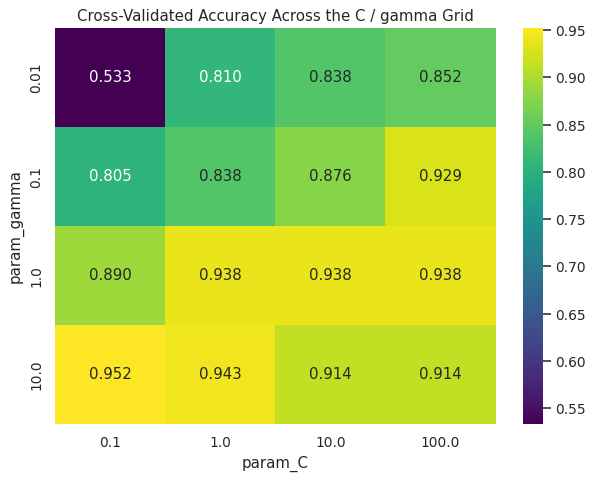

In [16]:
# Visualize the full grid as a heatmap -- exactly why C and gamma are searched TOGETHER, not
# one at a time: the best gamma often depends on which C is paired with it.
results_grid = pd.DataFrame(grid.cv_results_)
pivot = results_grid.pivot(index='param_gamma', columns='param_C', values='mean_test_score')

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_title('Cross-Validated Accuracy Across the C / gamma Grid')
plt.tight_layout()
plt.show()

**Notice the best score doesn't necessarily sit at the extreme corner of either parameter** --
`C` and `gamma` interact, which is exactly why scikit-learn practice searches a 2D grid jointly
rather than tuning one parameter, fixing it, then tuning the other.

---
## Part 11 -- Multiclass SVM: One-vs-One

In [17]:
X_multi, y_multi = make_blobs(n_samples=300, centers=3, cluster_std=1.5, random_state=7)
labels = ['Budget', 'Standard', 'Premium']

multi_svm = SVC(kernel='rbf', decision_function_shape='ovo')   # One-vs-One, scikit-learn's default
multi_svm.fit(X_multi, y_multi)

print(f'Number of binary SVMs trained under the hood (k(k-1)/2 for k=3 classes): '
      f'{multi_svm.decision_function(X_multi[:1]).shape[1]}')

Number of binary SVMs trained under the hood (k(k-1)/2 for k=3 classes): 3


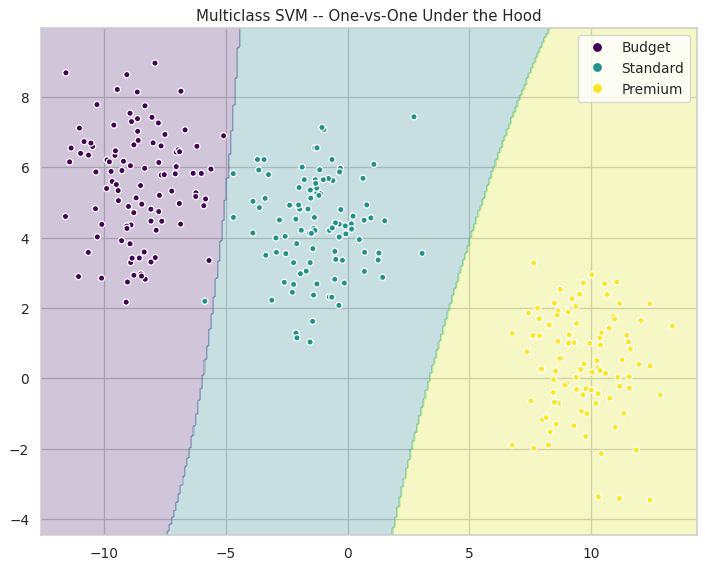

In [18]:
def boundary_panel_multiclass(model, X, y, ax, labels):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='viridis')
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='white', s=25)
    handles, _ = scatter.legend_elements()
    ax.legend(handles, labels)
    ax.set_title('Multiclass SVM -- One-vs-One Under the Hood')

fig, ax = plt.subplots(figsize=(8, 6.5))
boundary_panel_multiclass(multi_svm, X_multi, y_multi, ax, labels)
plt.tight_layout()
plt.show()

**`SVC` handled the 3-class problem automatically** -- exactly `k(k-1)/2 = 3` binary SVMs for 3
classes, combined by majority vote, with no extra code required. Calling `.fit()` on a multiclass
target just works, the same experience as `LogisticRegression` in Lecture 09, even though the
mechanism underneath (many binary SVMs voting) is completely different from softmax.

---
## Part 12 -- Four Families, Side by Side

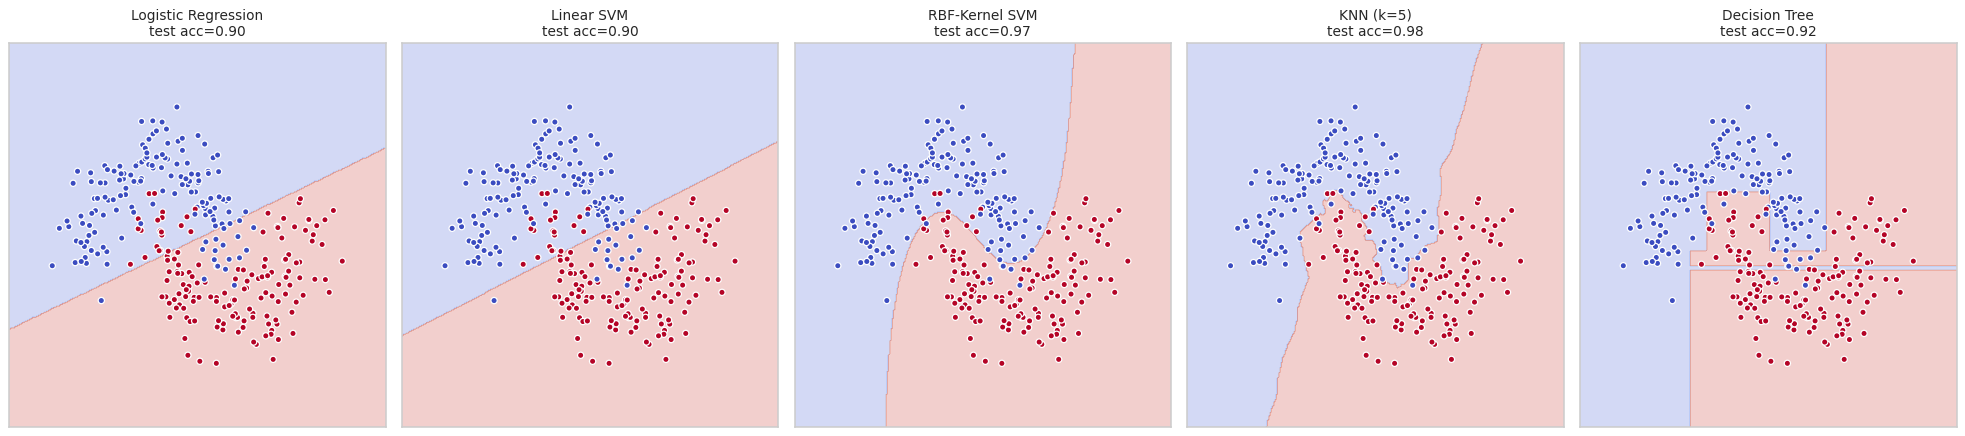

In [19]:
candidates = {
    'Logistic Regression': LogisticRegression(),
    'Linear SVM': SVC(kernel='linear', C=1),
    'RBF-Kernel SVM': SVC(kernel='rbf', C=1, gamma='scale'),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for ax, (name, model) in zip(axes, candidates.items()):
    model.fit(X_moons_train, y_moons_train)
    acc = model.score(X_moons_test, y_moons_test)
    plot_decision_boundary(model, X_moons, y_moons, ax, f'{name}\ntest acc={acc:.2f}')
plt.tight_layout()
plt.show()

**Same data, five genuinely different strategies for dividing it up.** Logistic Regression and
Linear SVM both produce a straight line (different lines, same shape constraint). RBF-kernel SVM
draws smooth curves. Decision Tree draws rectangular staircases. KNN draws an arbitrarily wiggly
boundary. None of these is "best" in general -- each makes a different structural assumption, and
matching that assumption to the true shape of your data is most of what choosing an algorithm
comes down to.

---
## Part 13 -- The Full Workflow, Tied Together

A self-contained churn-style dataset -- same shape of problem used throughout this course.

In [20]:
rng = np.random.default_rng(42)
n = 800
tenure_months = rng.integers(1, 72, n)
monthly_charges = rng.normal(70, 25, n).clip(20, 150)
contract_month_to_month = rng.choice([0, 1], n, p=[0.45, 0.55])

churn_score = (-0.04 * tenure_months + 0.02 * monthly_charges + 1.3 * contract_month_to_month - 2.3
               + rng.normal(0, 1, n))
churn_prob_true = 1 / (1 + np.exp(-churn_score))
churn = rng.binomial(1, churn_prob_true)

churn_df = pd.DataFrame({'tenure_months': tenure_months, 'monthly_charges': monthly_charges,
                          'contract_month_to_month': contract_month_to_month, 'churn': churn})

X = churn_df[['tenure_months', 'monthly_charges', 'contract_month_to_month']]
y = churn_df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# Scaling is NON-NEGOTIABLE for SVM -- it's a distance/margin-based method, exactly like KNN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Churn rate: {churn_df["churn"].mean():.1%}')

Churn rate: 26.1%


In [21]:
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1]}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=cv, scoring='f1')
grid.fit(X_train_scaled, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best cross-validated F1: {grid.best_score_:.3f}')

final_svm = grid.best_estimator_
final_preds = final_svm.predict(X_test_scaled)
print()
print(classification_report(y_test, final_preds, target_names=['Stay', 'Churn']))

Best parameters: {'C': 100, 'gamma': 1}
Best cross-validated F1: 0.362

              precision    recall  f1-score   support

        Stay       0.78      0.86      0.82       148
       Churn       0.43      0.29      0.34        52

    accuracy                           0.71       200
   macro avg       0.60      0.58      0.58       200
weighted avg       0.69      0.71      0.69       200



Test ROC-AUC (via decision_function, no probability calibration needed): 0.630


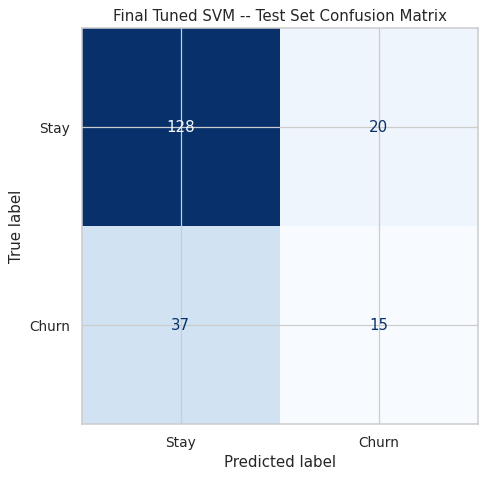

In [22]:
# SVM has no native predict_proba -- decision_function() gives a raw margin-distance score
# instead, which roc_auc_score accepts directly, without needing the costly probability=True
# calibration step.
decision_scores = final_svm.decision_function(X_test_scaled)
print(f'Test ROC-AUC (via decision_function, no probability calibration needed): '
      f'{roc_auc_score(y_test, decision_scores):.3f}')

fig, ax = plt.subplots(figsize=(6, 5.5))
cm = confusion_matrix(y_test, final_preds)
ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Final Tuned SVM -- Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

**Every step is a technique from an earlier lecture, pointed at a new algorithm:** `StandardScaler`
from Lecture 05 (essential here, not optional), `StratifiedKFold` + `GridSearchCV` over a 2D grid
from Lecture 04, `classification_report` and `ConfusionMatrixDisplay` from Lecture 06. The one
genuinely new wrinkle is `decision_function()` standing in for `predict_proba()` -- worth
remembering any time ROC-AUC is needed from an `SVC`.

---
## Summary

| Part | Technique | Key operation |
|---|---|---|
| **The margin** | Maximum-margin boundary | `SVC(kernel='linear')`, visualized via `decision_function()` at levels -1, 0, 1 |
| **Support vectors** | The sparse solution | `.support_vectors_`, `.n_support_` -- often a small fraction of the data |
| **Hard vs. soft margin** | Tolerating violations | Large `C` ≈ hard margin; small `C` = genuinely soft, more tolerant |
| **Hinge loss** | `max(0, 1 - y*z)` | Zero cost once a point clears the margin -- unlike log loss |
| **C parameter** | Margin width vs. fit | Small C = wide margin, more bias; large C = tight fit, more variance |
| **Linear limitation** | Still just a straight line | Demonstrated failing on `make_moons`, same as Logistic Regression |
| **Kernel trick** | Implicit lift to a higher space | `kernel='rbf'`/`'poly'`/`'sigmoid'` -- one word changes the boundary shape entirely |
| **Gamma** | How local each point's influence is | Small gamma = smooth/underfit; large gamma = tight/overfit |
| **Tuning** | C and gamma together | `GridSearchCV` over a 2D grid -- they interact, never tune one at a time |
| **Multiclass** | One-vs-One (default) | `k(k-1)/2` binary SVMs, combined by vote -- automatic in `.fit()` |
| **No native probabilities** | Use `decision_function()` | Works directly with `roc_auc_score`, no costly calibration needed |
| **Full workflow** | Nothing new, a new algorithm | Scale (non-negotiable) + `GridSearchCV` + the Lecture 06 evaluation toolkit |

---

**Next lecture:** Neural Networks and the Perceptron take a different route to the same flexibility
SVM's kernel trick provides -- stacking many simple linear-plus-nonlinearity units together,
starting from the same `w·x + b` building block this entire course has been using since Lecture 02.